In [26]:
with open('2.txt', 'r', encoding='utf-8') as file:
        text = file.read()

In [27]:
print(text[:1000])

Предисловие

   Превосходное творение Лесажа*, известное под названием "Похождения Жилблаза де-Сантиланы", принесло и продолжает приносить сколько удовольствия и пользы читающим, столько нести и удивления дарованиям издателя.
   Франция и Немеция имеют также своих героев*, коих похождения известны под названиями: "Французский Жилблаз", "Немецкий Жилблаз". А потому-то решился и я, следуя примеру, сие новое произведение мое выдать под столько известным именем и тем облегчить труд тех, нон стали бы изыскивать, с кем сравнивать меня в сем сочинении.
   Правила, которые сохранить предназначил я, суть вероятность, приличие, сходство описаний с природою, изображение нравов в различных состояниях и отношениях; цель всего точно та же, какую предначертал себе и Лесаж: соединить с приятным полезное.
   Но как сии два слова "приятность, польза" почти каждым понимаемы по-своему, и мы беспрестанно видим, -- если только подлинно смотрим, а не спим с открытыми глазами, -- что одну и ту же вещь, одно и

# Предобработка текста (обязательно)  
Очистка (убрать лишние переносы, заголовки, футеры, если есть)  
Токенизация и лемматизация (pymorphy2/3 или spaCy, др.)  
Удаление стоп-слов (по желанию — можно оставить для анализа стиля)


In [101]:
import re
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
from nltk.corpus import stopwords
nltk.download('stopwords')
from collections import Counter
from nltk.tokenize import sent_tokenize

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
#!pip install pymorphy3
import pymorphy3

In [28]:
test = text[:10000]

In [47]:
#удаляем из текста примечания в квадратных скобках и номера глав, затем
#удаляем пунктуацию, приводим все к одной строке и удаляем лишние пробелы

clean_text = re.sub(r'\[.*?\]', '', text)
clean_text = re.sub(r'Глава [A-Z]?\.', '', clean_text)
clean_text = re.sub(r'[^а-яА-ЯЁё\s]', ' ', clean_text.lower())
clean_text = re.sub(r'\n', ' ', clean_text)
clean_text = re.sub(r' +', ' ', clean_text)


In [48]:

clean_text[:10000]

'предисловие превосходное творение лесажа известное под названием похождения жилблаза де сантиланы принесло и продолжает приносить сколько удовольствия и пользы читающим столько нести и удивления дарованиям издателя франция и немеция имеют также своих героев коих похождения известны под названиями французский жилблаз немецкий жилблаз а потому то решился и я следуя примеру сие новое произведение мое выдать под столько известным именем и тем облегчить труд тех нон стали бы изыскивать с кем сравнивать меня в сем сочинении правила которые сохранить предназначил я суть вероятность приличие сходство описаний с природою изображение нравов в различных состояниях и отношениях цель всего точно та же какую предначертал себе и лесаж соединить с приятным полезное но как сии два слова приятность польза почти каждым понимаемы по своему и мы беспрестанно видим если только подлинно смотрим а не спим с открытыми глазами что одну и ту же вещь одно и то же чувствование движение желание отвращение один наз

In [49]:
#токенизируем
tokens = re.findall(r'\w+', clean_text)
len(tokens)

179897

In [46]:
#загрузим стоп-слова, чтобы удалить их из списка токенов
russian_stopwords = stopwords.words('russian')
print(russian_stopwords[:20])

['и', 'в', 'во', 'не', 'что', 'он', 'на', 'я', 'с', 'со', 'как', 'а', 'то', 'все', 'она', 'так', 'его', 'но', 'да', 'ты']


In [50]:
for token in tokens:
    if token in russian_stopwords:
        tokens.remove(token)

len(tokens)

127902

In [51]:
tokens[:15]

['предисловие',
 'превосходное',
 'творение',
 'лесажа',
 'известное',
 'названием',
 'похождения',
 'жилблаза',
 'де',
 'сантиланы',
 'принесло',
 'продолжает',
 'приносить',
 'сколько',
 'удовольствия']

In [35]:
#теперь будем лемматизировать, загрузим анализатор

morph = pymorphy3.MorphAnalyzer()

In [52]:
lemmas = []
for token in tokens:
    token_lemma = morph.parse(token)[0].normal_form
    lemmas.append(token_lemma)

In [62]:
lemmas[:15]

['предисловие',
 'превосходный',
 'творение',
 'лесажа',
 'известный',
 'название',
 'похождение',
 'жилблаз',
 'де',
 'сантилан',
 'принести',
 'продолжать',
 'приносить',
 'сколько',
 'удовольствие']

In [63]:
#у меня явно удалились не все стоп-слова, поэтому сделаю это еще раз с леммами

meaningful_lemmas = []
for lemma in lemmas:
    if lemma not in russian_stopwords:
        meaningful_lemmas.append(lemma)

len(meaningful_lemmas)

107092

# Частотный анализ

In [58]:
from nltk.probability import FreqDist

In [64]:
lemmas_frequencies = FreqDist(meaningful_lemmas)
print(lemmas_frequencies)

<FreqDist with 12178 samples and 107092 outcomes>


In [71]:
lemmas_frequencies.most_common(10)

[('свой', 1133),
 ('сказать', 1044),
 ('который', 847),
 ('князь', 760),
 ('человек', 691),
 ('это', 616),
 ('сей', 562),
 ('мочь', 553),
 ('дом', 466),
 ('рука', 449)]

In [67]:
#оставлю только существительные

only_nouns = []
for lemma in meaningful_lemmas:
    parsed = morph.parse(lemma)[0] #вот тут мне помог дипсик
    if 'NOUN' in parsed.tag:
        only_nouns.append(lemma)

In [68]:
noun_frequencies = FreqDist(only_nouns)
noun_frequencies.most_common(30)

[('князь', 760),
 ('человек', 691),
 ('мочь', 553),
 ('дом', 466),
 ('рука', 449),
 ('время', 414),
 ('отец', 384),
 ('день', 372),
 ('друг', 357),
 ('жена', 344),
 ('слово', 318),
 ('глаз', 311),
 ('никандр', 298),
 ('сердце', 296),
 ('бог', 267),
 ('дочь', 264),
 ('дело', 259),
 ('сын', 259),
 ('господин', 212),
 ('год', 204),
 ('иван', 194),
 ('голова', 187),
 ('муж', 180),
 ('елизавета', 177),
 ('симонович', 177),
 ('место', 173),
 ('имя', 166),
 ('жизнь', 166),
 ('любовь', 163),
 ('деньга', 159)]

In [ ]:
#!pip install wordcloud matplotlib

from wordcloud import WordCloud
import matplotlib.pyplot as plt

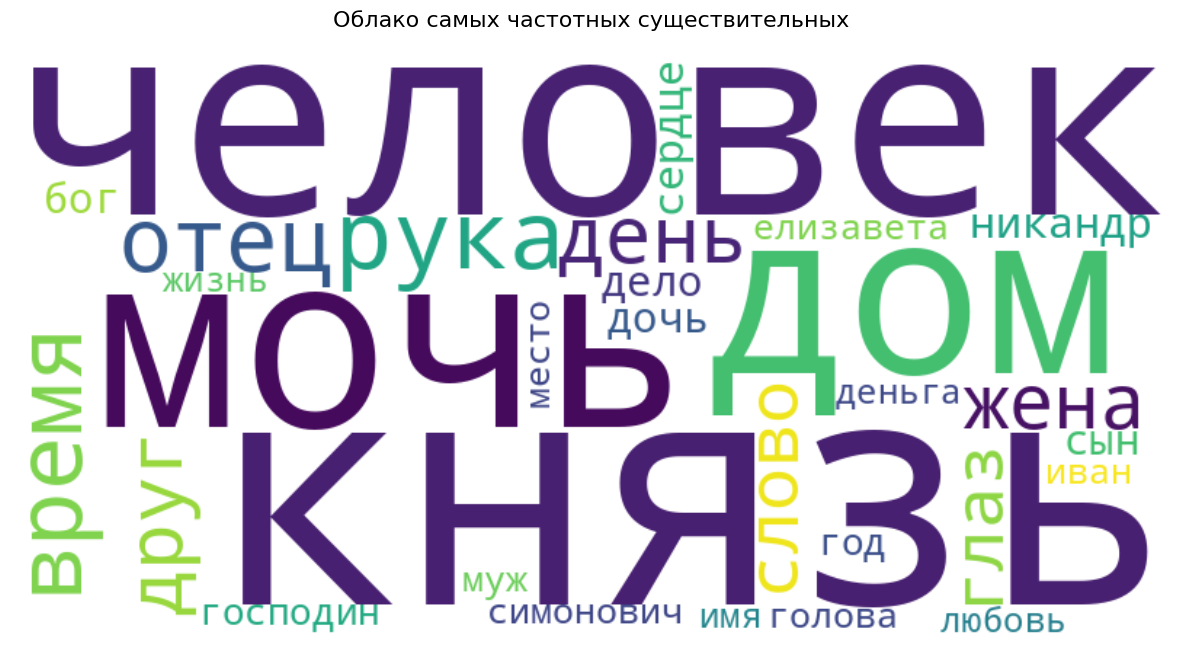

In [70]:
#покажем частотные существительные на облаке слов - тут тоже помог дипсик
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white',
    colormap='viridis',
    max_words=30,
    random_state=42,
    contour_width=1,
    contour_color='steelblue'
).generate_from_frequencies(dict(noun_frequencies))

plt.figure(figsize=(15, 8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Облако самых частотных существительных', fontsize=16, pad=20)
plt.show()

In [77]:
#попробуем то же самое для глаголов

only_verbs = []
for lemma in meaningful_lemmas:
    parsed = morph.parse(lemma)[0]
    if 'INFN' in parsed.tag: #обозначение INFN нашла методом научного тыка
        only_verbs.append(lemma)

verb_frequencies = FreqDist(only_verbs)
verb_frequencies.most_common(15)

[('сказать', 1044),
 ('говорить', 443),
 ('знать', 436),
 ('видеть', 327),
 ('отвечать', 315),
 ('хотеть', 293),
 ('иметь', 289),
 ('сделать', 275),
 ('делать', 273),
 ('думать', 264),
 ('спросить', 227),
 ('выйти', 218),
 ('увидеть', 214),
 ('вскричать', 212),
 ('смотреть', 187)]

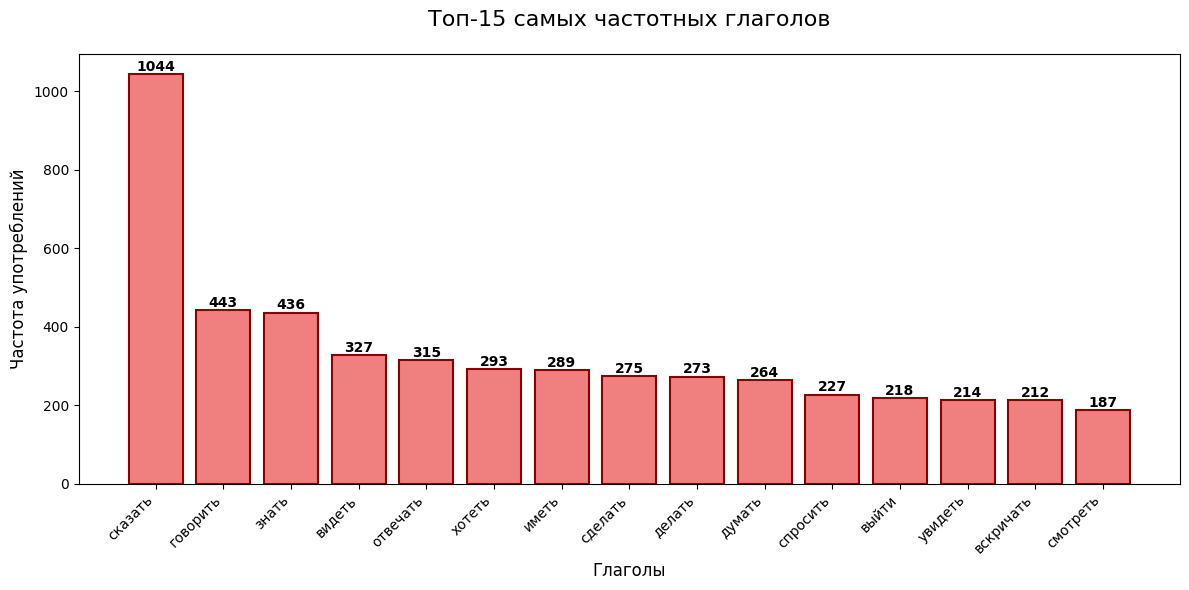

In [79]:
#построим столбчатую диаграмму - тут, не буду скрывать, тоже помог дипсик

verbs, counts = zip(*verb_frequencies.most_common(15))

plt.figure(figsize=(12, 6))
plt.bar(verbs, counts, color='lightcoral', edgecolor='darkred', linewidth=1.5)
plt.title('Топ-15 самых частотных глаголов', fontsize=16, pad=20)
plt.xlabel('Глаголы', fontsize=12)
plt.ylabel('Частота употреблений', fontsize=12)
plt.xticks(rotation=45, ha='right')
for i, (verb, count) in enumerate(zip(verbs, counts)):
    plt.text(i, count + 0.5, str(count), ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.show()

In [88]:
#вернемся на этап токенов и попробуем посчитать, в каких временах употребляются глаголы

verbs_in_tokens = []
for token in tokens:
    parsed = morph.parse(token)[0]
    if ('VERB' in parsed.tag) or ('INFN' in parsed.tag):
        verbs_in_tokens.append(token)

#когда работали с леммами, использовали INFN, тк все лемматизированные глаголы - инфинитивы
#а тут токены, поэтому берем VERB тоже

In [87]:
verbs_in_tokens[:20]

['принесло',
 'продолжает',
 'приносить',
 'нести',
 'имеют',
 'решился',
 'выдать',
 'облегчить',
 'стали',
 'изыскивать',
 'сравнивать',
 'сохранить',
 'предназначил',
 'суть',
 'предначертал',
 'соединить',
 'видим',
 'смотрим',
 'спим',
 'называет']

In [91]:
tenses_freqs = {}

for verb in verbs_in_tokens:
  parsed = morph.parse(verb)[0]
  tense = parsed.tag.tense
  if tense == None:
    tense = 'INFN' #тк у инфинитивов нет времени
  if tense in tenses_freqs:
        tenses_freqs[tense] += 1
  else:
        tenses_freqs[tense] = 1

tenses_freqs

{'past': 15333, 'pres': 3921, 'INFN': 6453, 'futr': 2139}

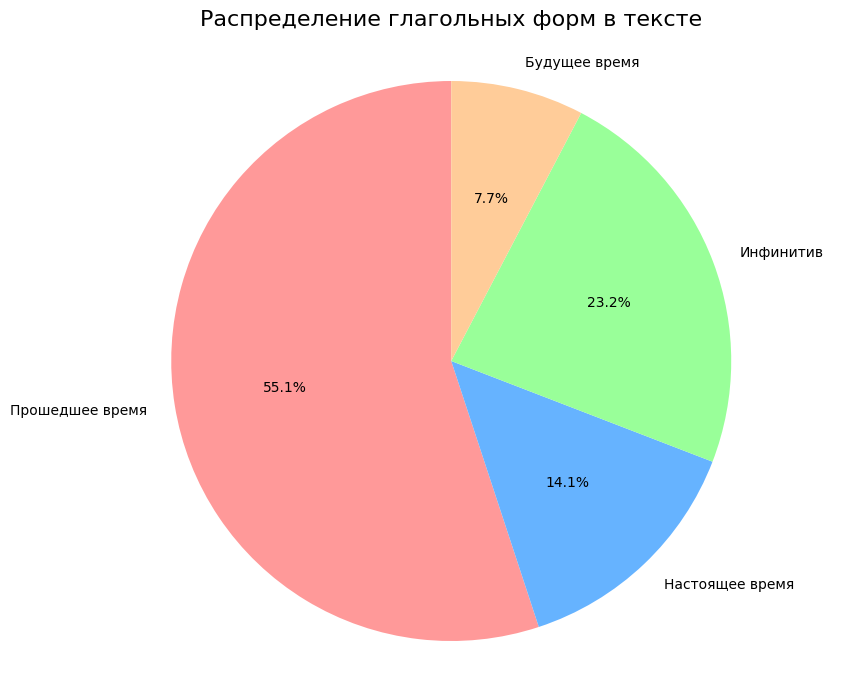


Статистика:
Прошедшее время: 15333 (55.1%)
Настоящее время: 3921 (14.1%)
Инфинитив: 6453 (23.2%)
Будущее время: 2139 (7.7%)


In [93]:
#строим КРУГОВУЮ ДИАГРАММУ (ну тут тоже дипсик помог)

labels_map = {
    'past': 'Прошедшее время',
    'pres': 'Настоящее время',
    'futr': 'Будущее время',
    'INFN': 'Инфинитив'
}

labels = [labels_map[key] for key in tenses_freqs.keys()]
sizes = list(tenses_freqs.values())

colors = ['#ff9999', '#66b3ff', '#99ff99', '#ffcc99']
plt.figure(figsize=(10, 8))
plt.pie(sizes, labels=labels, colors=colors,
        autopct='%1.1f%%', startangle=90)
plt.title('Распределение глагольных форм в тексте', fontsize=16, pad=20)
plt.axis('equal')
plt.show()
print("\nСтатистика:")
total = sum(sizes)
for label, size in zip(labels, sizes):
    print(f"{label}: {size} ({size/total*100:.1f}%)")

# Размер предложений

In [100]:
#вернемся к исходному тексту, теперь удалим только [примечания], главы и звездочки
new_clean_text = re.sub(r'\[.*?\]', '', text)
new_clean_text = re.sub(r'Глава [A-Z]?\.', '', new_clean_text)
new_clean_text = re.sub(r'\*', '', new_clean_text)
new_clean_text = re.sub(r'\n', ' ', new_clean_text)
new_clean_text = re.sub(r' +', ' ', new_clean_text)

new_clean_text[:300]

'Предисловие Превосходное творение Лесажа, известное под названием "Похождения Жилблаза де-Сантиланы", принесло и продолжает приносить сколько удовольствия и пользы читающим, столько нести и удивления дарованиям издателя. Франция и Немеция имеют также своих героев, коих похождения известны под назван'

In [102]:
sentences = sent_tokenize(new_clean_text, language='russian')

In [103]:
len(sentences)

13842

In [104]:
sentence_lengths = []
for sent in sentences:
  words = nltk.word_tokenize(sent, language='russian')
  words = [w for w in words if w.isalpha()]
  sentence_lengths.append(len(words))

In [105]:
sentence_lengths[:10]

[24, 16, 31, 33, 92, 25, 22, 4, 17, 34]

In [108]:
print(f"Всего предложений: {len(sentences)}")
print(f"Средняя длина: {sum(sentence_lengths) / len(sentences)} слов")
print(f"Максимальная длина: {max(sentence_lengths)} слов")

Всего предложений: 13842
Средняя длина: 12.865987574049992 слов
Максимальная длина: 101 слов
